# 04 - Train Model
Loads EfficientNetB0 pretrained on ImageNet, replaces the classifier head with a 3-class version, and defines the two-phase training strategy.

**What this notebook does:**
- Loads EfficientNetB0 via `timm` with ImageNet weights
- Freezes the backbone and replaces only the classifier head (Phase 1)
- Defines the optimizer, loss function, and learning rate scheduler
- Runs the full training loop with early stopping
- Unfreezes the last layers and fine-tunes at a lower learning rate (Phase 2)
- Saves the best model checkpoint

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import timm
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import copy
import time
import sys

In [18]:
GLOBAL_PATH = str(Path.cwd().parent.parent / "global")
if GLOBAL_PATH not in sys.path:
    sys.path.append(GLOBAL_PATH)
%reload_ext autoreload
%autoreload 2
import config
import utils

In [19]:
print(f"Device : {config.DEVICE} - {config.DEVICE_NAME}")

Device : cuda - NVIDIA GeForce RTX 3070


In [20]:
train_transforms = utils.get_transforms(True)
val_test_transforms = utils.get_transforms()
print(f"Train transforms : \t{len(train_transforms.transforms)} steps")
print(f"Val/test transforms : \t{len(val_test_transforms.transforms)} steps")

Train transforms : 	11 steps
Val/test transforms : 	3 steps


In [21]:
train_dataset = utils.EcuadorianDocumentsDataset(config.TRAIN_DIR, config.CLASSES, transform=train_transforms)
val_dataset   = utils.EcuadorianDocumentsDataset(config.VAL_DIR, config.CLASSES, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True,  pin_memory=(config.DEVICE.type=="cuda"))
val_loader   = DataLoader(val_dataset,   batch_size=config.BATCH_SIZE, shuffle=False, pin_memory=(config.DEVICE.type=="cuda"))

print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images")

Train: 191 images | Val: 42 images


In [22]:
def build_model(num_classes: int = 3, freeze_backbone: bool = True) -> nn.Module:
    """
    Loads EfficientNetB0 pretrained on ImageNet.
    Replaces the classifier head with a custom 3-class head.

    Args:
        num_classes:      number of output classes
        freeze_backbone:  if True, only the head is trainable (Phase 1)
                          if False, entire model is trainable (Phase 2)
    """
    # timm downloads weights automatically on first run (~20MB)
    model = timm.create_model(
        "efficientnet_b0",
        pretrained=True,
        num_classes=num_classes,   # replaces the head automatically
    )

    if freeze_backbone:
        # Freeze ALL parameters first
        for param in model.parameters():
            param.requires_grad = False

        # Unfreeze only the classifier head
        for param in model.classifier.parameters():
            param.requires_grad = True

    return model


def count_params(model: nn.Module):
    """Prints total and trainable parameter counts."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total params     : {total:,}")
    print(f"  Trainable params : {trainable:,}  ({trainable/total*100:.1f}%)")

In [23]:
# Build Phase 1 model (backbone frozen)
model = build_model(num_classes=config.NUM_CLASSES, freeze_backbone=True)
model = model.to(config.DEVICE)

print("Model built — Phase 1 (backbone frozen):")
count_params(model)
print(f"\nClassifier head: {model.classifier}")

Model built — Phase 1 (backbone frozen):
  Total params     : 4,012,672
  Trainable params : 5,124  (0.1%)

Classifier head: Linear(in_features=1280, out_features=4, bias=True)


In [24]:
criterion = nn.CrossEntropyLoss()


def run_epoch(model, loader, criterion, optimizer=None, phase="train"):
    """
    Runs one full epoch (train or val).

    Args:
        model:     the neural network
        loader:    DataLoader for this phase
        criterion: loss function
        optimizer: pass None for val/test (no weight updates)
        phase:     'train' or 'val'

    Returns:
        avg_loss (float), accuracy (float 0-1)
    """
    is_training = (phase == "train")
    model.train() if is_training else model.eval()

    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    # torch.no_grad() skips gradient computation during val — faster + less memory
    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        for images, labels in loader:
            images = images.to(config.DEVICE)
            labels = labels.to(config.DEVICE)

            # Forward pass
            logits = model(images)              # shape: [batch, num_classes]
            loss   = criterion(logits, labels)

            if is_training:
                optimizer.zero_grad()
                loss.backward()                 # compute gradients
                optimizer.step()                # update weights

            # Accumulate stats
            total_loss    += loss.item() * images.size(0)
            preds          = logits.argmax(dim=1)
            correct       += (preds == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples
    return avg_loss, accuracy


def plot_history(history: dict, title: str = ""):
    """Plots train/val loss and accuracy curves."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], label="Train", color="#5DCAA5")
    ax1.plot(epochs, history["val_loss"],   label="Val",   color="#7F77DD")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.legend()
    ax1.spines[["top", "right"]].set_visible(False)

    ax2.plot(epochs, history["train_acc"], label="Train", color="#5DCAA5")
    ax2.plot(epochs, history["val_acc"],   label="Val",   color="#7F77DD")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.spines[["top", "right"]].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [ ]:
P1_EPOCHS   = 15
P1_LR       = 1e-3
PATIENCE    = 5

optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=P1_LR
)

scheduler_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode="min", factor=0.5, patience=2
)

history_p1 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_loss  = float("inf")
best_weights   = copy.deepcopy(model.state_dict())
patience_count = 0

print(f"Phase 1 — training head only for up to {P1_EPOCHS} epochs (early stop patience={PATIENCE})")
print("-" * 65)

for epoch in range(1, P1_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer_p1, phase="train")
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion, optimizer=None, phase="val")

    scheduler_p1.step(val_loss)

    history_p1["train_loss"].append(train_loss)
    history_p1["val_loss"].append(val_loss)
    history_p1["train_acc"].append(train_acc)
    history_p1["val_acc"].append(val_acc)

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{P1_EPOCHS} | "
        f"Train loss {train_loss:.4f} acc {train_acc:.3f} | "
        f"Val loss {val_loss:.4f} acc {val_acc:.3f} | "
        f"{elapsed:.1f}s"
    )

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_weights   = copy.deepcopy(model.state_dict())
        patience_count = 0
        print(f"  -> New best val loss: {best_val_loss:.4f}  (checkpoint saved)")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"  -> Early stopping triggered after {epoch} epochs")
            break

# Restore best weights
model.load_state_dict(best_weights)
print(f"\nPhase 1 complete. Best val loss: {best_val_loss:.4f}")

Phase 1 — training head only for up to 20 epochs (early stop patience=5)
-----------------------------------------------------------------
Epoch 01/20 | Train loss 3.6319 acc 0.298 | Val loss 4.5537 acc 0.238 | 3.3s
  -> New best val loss: 4.5537  (checkpoint saved)
Epoch 02/20 | Train loss 2.9765 acc 0.325 | Val loss 4.1573 acc 0.286 | 2.0s
  -> New best val loss: 4.1573  (checkpoint saved)
Epoch 03/20 | Train loss 3.0836 acc 0.325 | Val loss 4.0472 acc 0.262 | 1.9s
  -> New best val loss: 4.0472  (checkpoint saved)
Epoch 04/20 | Train loss 2.7188 acc 0.356 | Val loss 3.7753 acc 0.286 | 1.9s
  -> New best val loss: 3.7753  (checkpoint saved)
Epoch 05/20 | Train loss 2.7288 acc 0.408 | Val loss 3.6101 acc 0.286 | 2.0s
  -> New best val loss: 3.6101  (checkpoint saved)
Epoch 06/20 | Train loss 2.5622 acc 0.414 | Val loss 3.4420 acc 0.286 | 1.9s
  -> New best val loss: 3.4420  (checkpoint saved)
Epoch 07/20 | Train loss 2.3050 acc 0.440 | Val loss 3.1469 acc 0.310 | 2.0s
  -> New best va

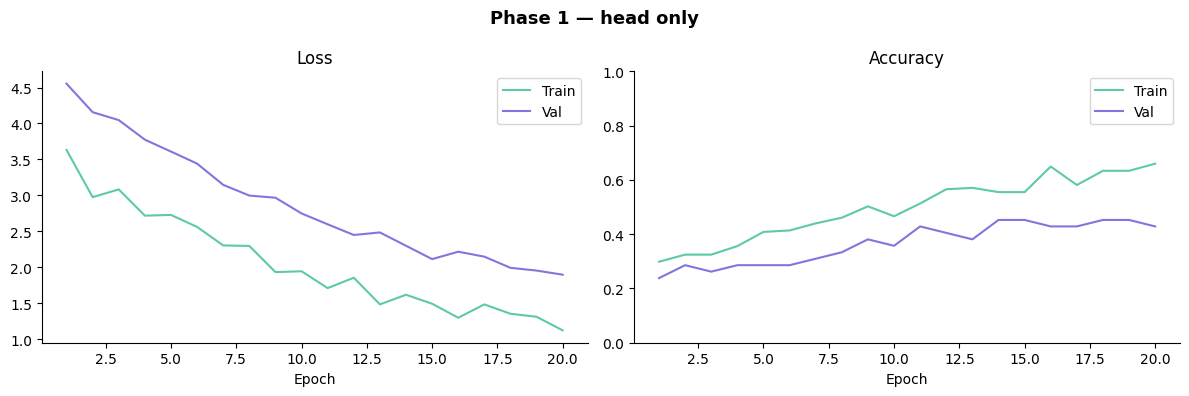

In [26]:
plot_history(history_p1, title="Phase 1 — head only")

In [27]:
# Unfreeze the last 3 blocks of EfficientNet + the head
# EfficientNet blocks are in model.blocks — we unfreeze the last 3
blocks = list(model.blocks.children())
for block in blocks[-3:]:
    for param in block.parameters():
        param.requires_grad = True

# Always keep head unfrozen
for param in model.classifier.parameters():
    param.requires_grad = True

print("Phase 2 — unfrozen layers:")
count_params(model)

Phase 2 — unfrozen layers:
  Total params     : 4,012,672
  Trainable params : 3,291,852  (82.0%)


In [ ]:
# ── Phase 2 hyperparameters ─────────────────────────────────────────
P2_EPOCHS = 35
P2_LR     = 1e-5   # very low LR — just nudging the pretrained weights

optimizer_p2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=P2_LR
)

scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode="min", factor=0.5, patience=3
)

# ── Training loop ───────────────────────────────────────────────────
history_p2 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_loss  = float("inf")
best_weights   = copy.deepcopy(model.state_dict())
patience_count = 0

print(f"Phase 2 — fine-tuning last 3 blocks for up to {P2_EPOCHS} epochs (patience={PATIENCE})")
print("-" * 65)

for epoch in range(1, P2_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer_p2, phase="train")
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion, optimizer=None, phase="val")

    scheduler_p2.step(val_loss)

    history_p2["train_loss"].append(train_loss)
    history_p2["val_loss"].append(val_loss)
    history_p2["train_acc"].append(train_acc)
    history_p2["val_acc"].append(val_acc)

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{P2_EPOCHS} | "
        f"Train loss {train_loss:.4f} acc {train_acc:.3f} | "
        f"Val loss {val_loss:.4f} acc {val_acc:.3f} | "
        f"{elapsed:.1f}s"
    )

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_weights   = copy.deepcopy(model.state_dict())
        patience_count = 0
        print(f"  -> New best val loss: {best_val_loss:.4f}  (checkpoint saved)")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"  -> Early stopping triggered after {epoch} epochs")
            break

model.load_state_dict(best_weights)
print(f"\nPhase 2 complete. Best val loss: {best_val_loss:.4f}")

Phase 2 — fine-tuning last 3 blocks for up to 25 epochs (patience=5)
-----------------------------------------------------------------
Epoch 01/25 | Train loss 1.2707 acc 0.649 | Val loss 1.9311 acc 0.452 | 2.9s
  -> New best val loss: 1.9311  (checkpoint saved)
Epoch 02/25 | Train loss 1.3298 acc 0.660 | Val loss 1.9637 acc 0.476 | 1.8s
Epoch 03/25 | Train loss 1.1738 acc 0.681 | Val loss 1.8623 acc 0.476 | 1.8s
  -> New best val loss: 1.8623  (checkpoint saved)
Epoch 04/25 | Train loss 1.3207 acc 0.634 | Val loss 1.8616 acc 0.548 | 2.0s
  -> New best val loss: 1.8616  (checkpoint saved)
Epoch 05/25 | Train loss 1.0550 acc 0.686 | Val loss 1.7975 acc 0.548 | 2.0s
  -> New best val loss: 1.7975  (checkpoint saved)
Epoch 06/25 | Train loss 1.0583 acc 0.649 | Val loss 1.8429 acc 0.548 | 2.0s
Epoch 07/25 | Train loss 1.2771 acc 0.654 | Val loss 1.6551 acc 0.548 | 2.0s
  -> New best val loss: 1.6551  (checkpoint saved)
Epoch 08/25 | Train loss 1.0345 acc 0.686 | Val loss 1.7907 acc 0.548 |

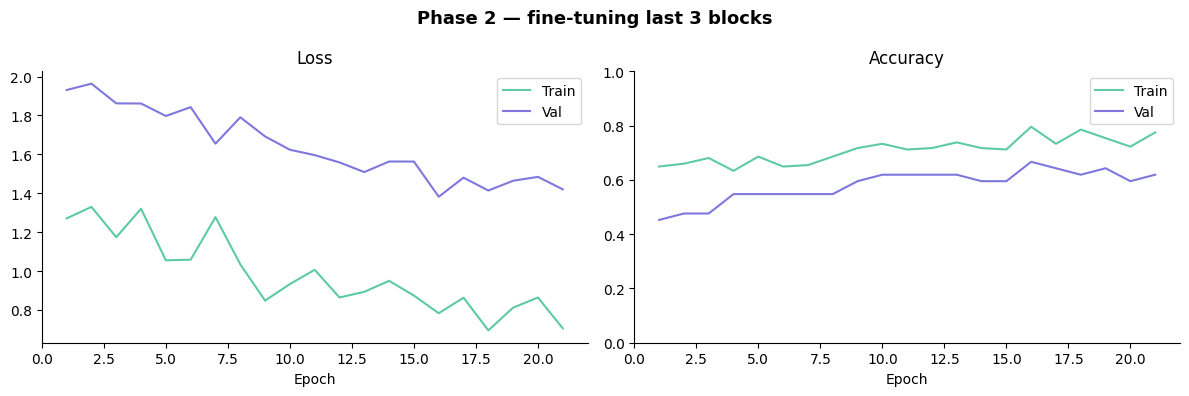

In [29]:
plot_history(history_p2, title="Phase 2 — fine-tuning last 3 blocks")

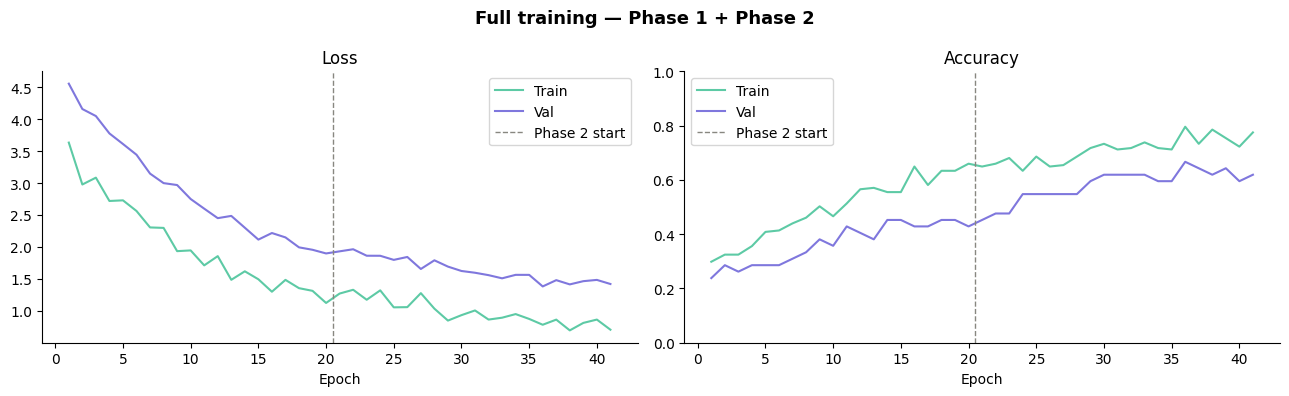

In [30]:
combined = {
    "train_loss": history_p1["train_loss"] + history_p2["train_loss"],
    "val_loss"  : history_p1["val_loss"]   + history_p2["val_loss"],
    "train_acc" : history_p1["train_acc"]  + history_p2["train_acc"],
    "val_acc"   : history_p1["val_acc"]    + history_p2["val_acc"],
}

p1_end = len(history_p1["train_loss"])
epochs = range(1, len(combined["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in [
    (ax1, "loss", "Loss"),
    (ax2, "acc",  "Accuracy"),
]:
    ax.plot(epochs, combined[f"train_{metric}"], label="Train", color="#5DCAA5")
    ax.plot(epochs, combined[f"val_{metric}"],   label="Val",   color="#7F77DD")
    ax.axvline(x=p1_end + 0.5, color="#888780", linestyle="--", linewidth=1, label="Phase 2 start")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    if metric == "acc":
        ax.set_ylim(0, 1)

fig.suptitle("Full training — Phase 1 + Phase 2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [31]:
checkpoint_path = config.PROJECT_ROOT / "best_model.pth"

torch.save({
    "model_state_dict"  : model.state_dict(),
    "model_name"        : "efficientnet_b0",
    "num_classes"       : config.NUM_CLASSES,
    "class_names"       : config.CLASS_NAMES,
    "img_size"          : config.IMAGE_SIZE,
    "imagenet_mean"     : config.IMAGENET_MEAN,
    "imagenet_std"      : config.IMAGENET_STD,
    "best_val_loss"     : best_val_loss,
    "history_p1"        : history_p1,
    "history_p2"        : history_p2,
}, checkpoint_path)

size_mb = checkpoint_path.stat().st_size / (1024 * 1024)
print(f"Checkpoint saved: {checkpoint_path}")
print(f"File size       : {size_mb:.1f} MB")
print(f"Best val loss   : {best_val_loss:.4f}")

Checkpoint saved: D:\Aprender\Projects\ecuadorian-id-classifier\best_model.pth
File size       : 15.6 MB
Best val loss   : 1.3820


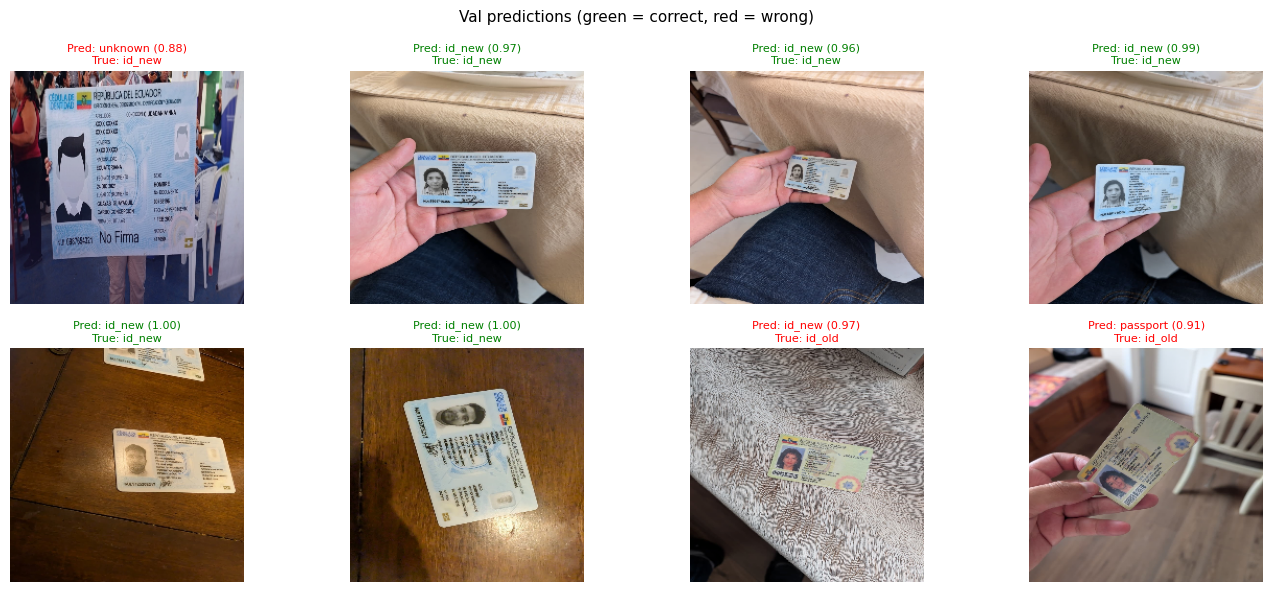

In [32]:
import torch.nn.functional as F

model.eval()
images_batch, labels_batch = next(iter(val_loader))
images_batch = images_batch.to(config.DEVICE)

with torch.no_grad():
    logits = model(images_batch)
    probs  = F.softmax(logits, dim=1)   # convert to probabilities
    preds  = probs.argmax(dim=1)

# Show first 8 predictions
n_show = min(8, len(images_batch))
mean   = torch.tensor(config.IMAGENET_MEAN).view(3,1,1)
std    = torch.tensor(config.IMAGENET_STD).view(3,1,1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for i in range(n_show):
    img  = images_batch[i].cpu() * std + mean
    img  = img.permute(1, 2, 0).numpy().clip(0, 1)
    pred = preds[i].item()
    true = labels_batch[i].item()
    conf = probs[i][pred].item()

    axes[i].imshow(img)
    color = "green" if pred == true else "red"
    axes[i].set_title(
        f"Pred: {config.CLASS_NAMES[pred]} ({conf:.2f})\nTrue: {config.CLASS_NAMES[true]}",
        fontsize=8, color=color
    )
    axes[i].axis("off")

for j in range(n_show, len(axes)):
    axes[j].axis("off")

fig.suptitle("Val predictions (green = correct, red = wrong)", fontsize=11)
plt.tight_layout()
plt.show()